<a href="https://colab.research.google.com/github/Shashank18ram/Data-Science/blob/main/TS_1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
data = np.array([1, 2, 3, 4])
print(np.cumsum(data))
# Output: [1, 3, 6, 10]

[ 1  3  6 10]


In [ ]:
data = np.cumsum(np.random.randn(100)) + np.linspace(0, 10, 100)
data

array([-0.66914187,  1.09032692,  2.28087099,  1.23424914,  1.89409929,
        1.22331701,  0.98934468,  1.58595479,  1.03734666,  1.1899925 ,
        1.34368057,  4.65920046,  2.88494941,  2.60727132,  3.35960992,
        3.91376879,  5.7377011 ,  6.99702055,  7.17197461,  7.2556859 ,
        7.0984734 ,  6.83716551,  8.73772409,  8.34896856,  8.87407968,
       10.21425383, 11.32498226, 10.12620623,  9.46123426,  8.2670995 ,
        7.80968953,  7.70301165,  7.20944963,  7.87231645,  7.16427108,
        7.19312392,  5.78864888,  5.03324841,  4.97193106,  3.40589186,
        2.86381033,  2.65711485,  1.72934161,  2.01205275,  1.67891481,
        1.52402383,  2.46070241,  1.95780906,  3.11483728,  2.46282633,
        1.52339651,  1.60987057,  0.0145709 , -1.42245774, -1.55582737,
       -0.67800545, -0.27303399,  0.31876948,  0.56335973,  0.73323906,
       -0.23893842, -1.69717495, -2.29148648, -3.96171158, -3.48956889,
       -3.16345863, -4.37693043, -6.43006541, -5.6226861 , -4.03

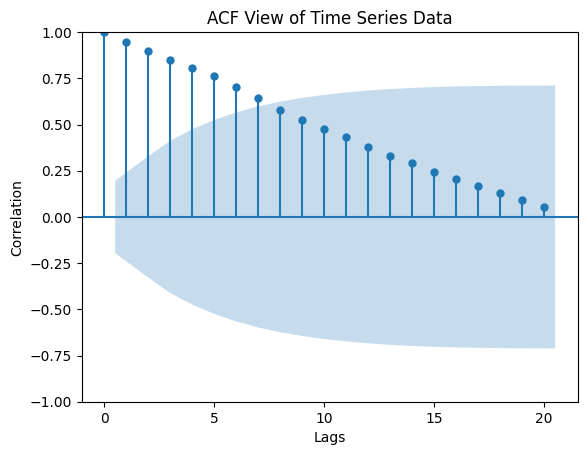

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# 1. Create a dummy Time Series (Random walk with a trend)
np.random.seed(42)
data = np.cumsum(np.random.randn(100)) + np.linspace(0, 10, 100)

# 2. Plot the ACF
# The 'lags' parameter defines how many time steps back we look
plot_acf(data, lags=20)
plt.title("ACF View of Time Series Data")
plt.xlabel("Lags")
plt.ylabel("Correlation")
plt.show()

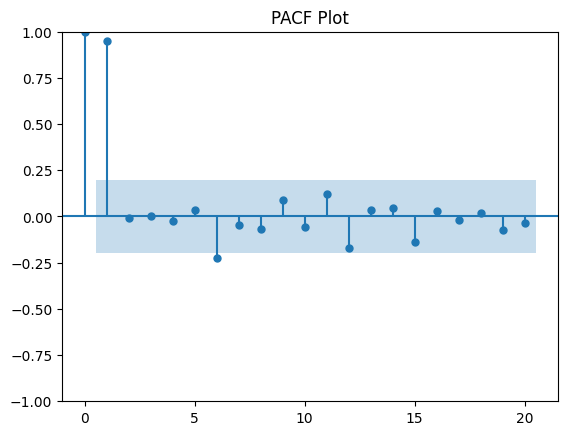

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

# Assuming 'data' is your time series array
plot_pacf(data, lags=20, method='ywm')
plt.title("PACF Plot")
plt.show()

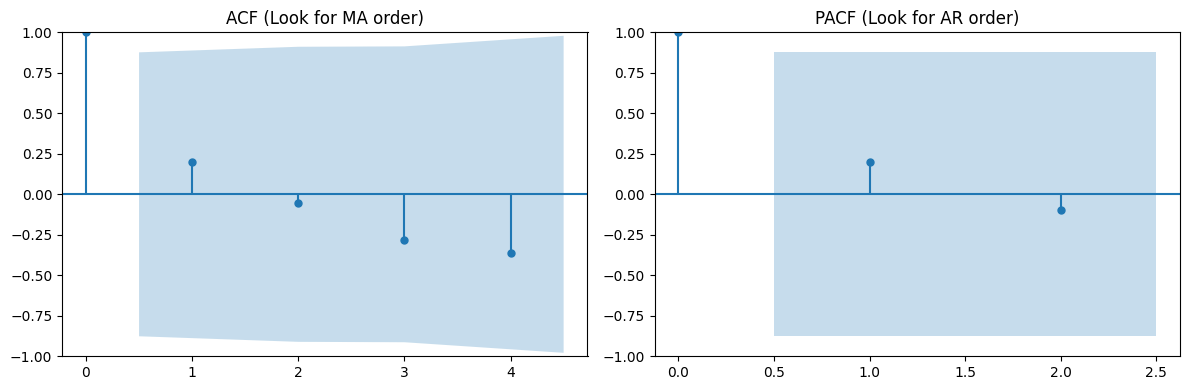

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Your data from the spreadsheet
# [5, 7, 6, 9, 10]
sales_data = [5, 7, 6, 9, 10]

# 2. Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 3. Plot ACF (Autocorrelation)
# Useful for identifying the MA (Moving Average) order
plot_acf(sales_data, lags=4, ax=ax1)
ax1.set_title("ACF (Look for MA order)")

# 4. Plot PACF (Partial Autocorrelation)
# Useful for identifying the AR (Auto-Regressive) order
plot_pacf(sales_data, lags=2, method='ywm', ax=ax2)
ax2.set_title("PACF (Look for AR order)")

plt.tight_layout()
plt.show()



Because the bars for Lag 1 and Lag 2 stay **inside the blue shaded area**, the statistical "meaning" for your sales is as follows:

### 1. Tuesday vs. Monday (Lag 1)

* **The Outcome:** The correlation bar at Lag 1 is small and stays within the blue zone.
* **The Meaning:** You cannot say that Tuesday’s sales are influenced by Monday’s sales. As far as the model is concerned, Tuesday's "7" and Monday's "5" are **independent events**. There isn't enough consistent "memory" in this small data set to prove that a good Monday leads to a good Tuesday.

### 2. Wednesday vs. Monday (Lag 2)

* **The Outcome:** The bar at Lag 2 is even smaller (and in your graph, it actually dips slightly negative).
* **The Meaning:** Monday has **zero visible "echo"** on Wednesday. Whatever happened at the start of the week is completely "forgotten" by the time Wednesday rolls around.

---

### Why "Not Visible" doesn't mean "Not Happening"

It is important to distinguish between **"No Influence"** and **"Insignificant Influence."**

* **In the real world:** We know that often a busy Monday *does* affect Tuesday (maybe you ran out of stock, or customers are still talking about you).
* **In your Graph:** The graph is saying: *"I see these numbers, but because you only gave me 5 days of data, I have to assume any relationship is just a coincidence (noise)."*

### How a "Significant" result would look

If the influence **were** visible and significant, your interpretation would change to:

> "Monday's sales have a **statistically significant positive impact** on Tuesday. If Monday's sales go up by 1 unit, we can reliably predict Tuesday's sales will rise by 0.8 units."

### Summary for your [Spreadsheet](https://docs.google.com/spreadsheets/d/1migbH_75hLKZnyer1I-GxOm9MghjtuIrf_TeilGBWts/edit#gid=1082524499) Data:

Since all your bars are in the blue:

* **Prediction value:** Low. You can't use past sales to predict future sales yet.
* **Model needed:** Currently, this looks like **White Noise** (randomness) rather than an AR or MA process.

Does it make sense why the "Blue Zone" is essentially the "Zone of Silence" for your data?

For the **PACF (Partial Autocorrelation Function)** of your [sales dataset](https://docs.google.com/spreadsheets/d/1migbH_75hLKZnyer1I-GxOm9MghjtuIrf_TeilGBWts/edit#gid=1082524499), the interpretation is very similar but focuses on the **direct** connection between days.

Since your PACF bars in the [Colab notebook](https://colab.research.google.com/drive/1i90gCnIv9QwnlZuPFaCp7QgX7qB_vnr6#scrollTo=dcJEUfJLpmsn) are also inside the blue shaded area, here is the breakdown:

### 1. Tuesday vs. Monday (Lag 1)

* **The Outcome:** The bar is inside the blue zone.
* **The Meaning:** Monday's sales do not have a strong enough **direct** link to Tuesday's sales to be useful for a forecast. In "sales talk," this means that knowing Monday was a "5" gives you no statistical advantage in guessing that Tuesday would be a "7." They are effectively independent.

### 2. Wednesday vs. Monday (Lag 2)

* **The Outcome:** The bar is inside the blue zone (and often very close to zero).
* **The Meaning:** There is no direct "jump" from Monday to Wednesday. The PACF specifically checks: *"If we ignore what happened on Tuesday, does Monday still affect Wednesday?"* The answer here is **No**. Monday has no "lingering" direct power over the middle of your week.

---

### Why the PACF is "Empty" (The Meaning of the Blue Zone)

In a professional setting, if your manager asked you to predict next Monday's sales based on this PACF graph, your answer would be:

> "The data shows no significant internal momentum. Based on these 5 days, our sales are currently behaving like **random noise**. We cannot say that a good day yesterday directly causes a good day today."

### The "AR" Connection

The PACF is the "Scanner" for **AR (Auto-Regressive)** patterns:

* **If you had a significant Lag 1:** It would mean the data is "self-driving" (today is built directly on yesterday).
* **Because it's insignificant:** It means your data is not "self-driving." Any increase you see (like the jump from 6 to 9) is being treated by the model as a **random spike**, not a predictable trend.

### Comparison Summary

| Graph | What it asks | Your Result |
| --- | --- | --- |
| **ACF** | Does the *overall* past affect today? | **No** (Insignificant) |
| **PACF** | Does a *specific* past day *directly* affect today? | **No** (Insignificant) |

**Conclusion for your current data:** You have a "Random Walk" with too few data points to prove the walk isn't just a series of coincidences.

Does this help clarify why both graphs are telling you to be careful about making predictions yet?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as  plt

In [ ]:
df = pd.read_csv(r'/content/footfalls.csv')
df.head()

,Month,Footfalls
0,Jan-91,1709
1,Feb-91,1621
2,Mar-91,1973
3,Apr-91,1812
4,May-91,1975


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Month      159 non-null    object
 1   Footfalls  159 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.6+ KB


In [ ]:
df['Month'] = pd.to_datetime(df['Month'], format='%b-%y')

In [ ]:
df

,Month,Footfalls
0,1991-01-01,1709
1,1991-02-01,1621
2,1991-03-01,1973
3,1991-04-01,1812
4,1991-05-01,1975
...,...,...
154,2003-11-01,2076
155,2003-12-01,2141
156,2004-01-01,1832
157,2004-02-01,1838


In [ ]:
df.reset_index(drop=True, inplace=True)

In [ ]:
df.set_index('Month', inplace=True)

In [ ]:
df.head()

,Footfalls
Month,
1991-01-01,1709
1991-02-01,1621
1991-03-01,1973
1991-04-01,1812
1991-05-01,1975


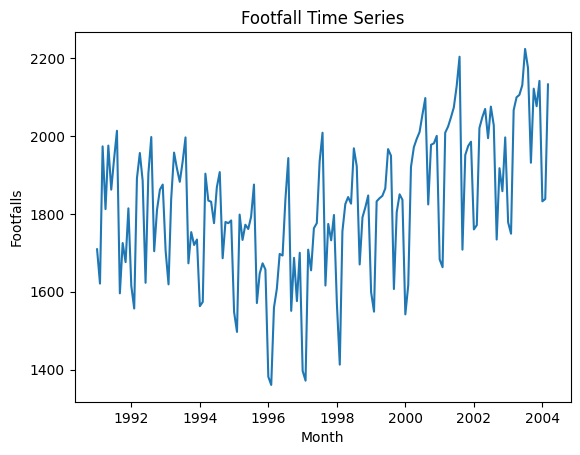

In [ ]:
#let us plot the series
plt.plot(df)
plt.xlabel('Month')
plt.ylabel('Footfalls')
plt.title('Footfall Time Series')
plt.show()

An upward trend over the years.

A clear seasonal pattern — regular peaks and troughs repeating every year.

To confirm that the trend is not stationary, let us do Dicky fuller test on the footfalls.

# Step 5: Difference the series

#Step6 : Fit the AR model with lags=1

#Fit the ARIMA model with MA(Lags 1)


# Fit the ARIMA model with ARIMA(Lags 1)